# 04 — Headline results

A short, plot-driven version of notebook 03 for non-technical readers. Two
figures and one verdict.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from swp import features, stats as swstats
from swp.io import DATA_PROCESSED, FIGURES

FIGURES.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260501)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140

codas = pd.read_parquet(DATA_PROCESSED / "whale_codas.parquet")
vedic = pd.read_parquet(DATA_PROCESSED / "vedic_syllables.parquet")

whale_ici = [list(s) for s in codas["ici_seq"].tolist() if len(s) > 0]
vedic_weights = (
    vedic.sort_values(["verse_id", "syllable_idx"])
         .groupby("verse_id", sort=False)["weight"]
         .apply(list)
         .tolist()
)
vedic_weights = [s for s in vedic_weights if len(s) >= 2]
vedic_durations = [features.weights_to_durations(s).tolist() for s in vedic_weights]
print(f"loaded {len(whale_ici):,} codas and {len(vedic_weights):,} pādas")


loaded 12,542 codas and 39,717 pādas


## Headline 1 — sequence length distributions

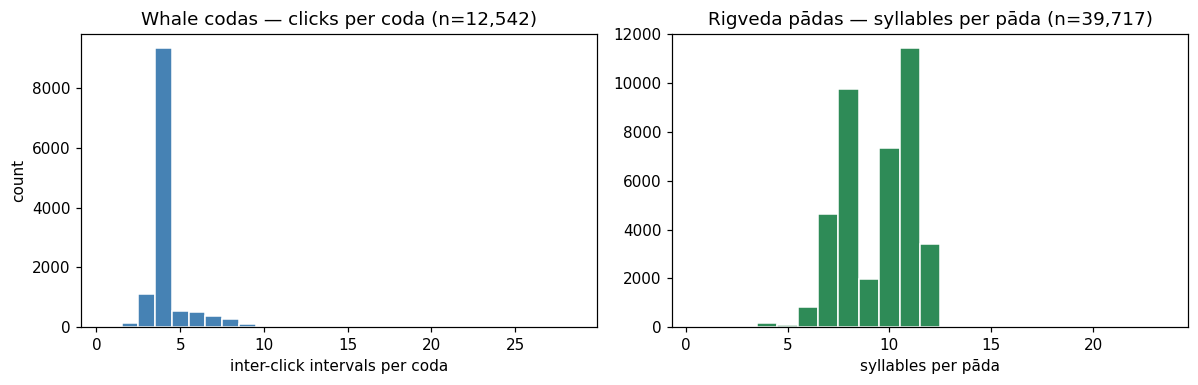

In [2]:
whale_lens = np.asarray([len(s) for s in whale_ici])
vedic_lens = np.asarray([len(s) for s in vedic_weights])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(whale_lens, bins=np.arange(1, whale_lens.max() + 2) - 0.5,
             color="steelblue", edgecolor="white")
axes[0].set_title(f"Whale codas — clicks per coda (n={len(whale_lens):,})")
axes[0].set_xlabel("inter-click intervals per coda"); axes[0].set_ylabel("count")

axes[1].hist(vedic_lens, bins=np.arange(1, max(vedic_lens.max() + 2, 25)) - 0.5,
             color="seagreen", edgecolor="white")
axes[1].set_title(f"Rigveda pādas — syllables per pāda (n={len(vedic_lens):,})")
axes[1].set_xlabel("syllables per pāda")

fig.tight_layout()
fig.savefig(FIGURES / "04_sequence_lengths.png", bbox_inches="tight")
plt.show()


## Headline 2 — z-scored IOI distributions, side by side

Whale and Vedic units differ (seconds vs mātrās), so we standardise within
each corpus and compare the *shapes* of the resulting distributions.


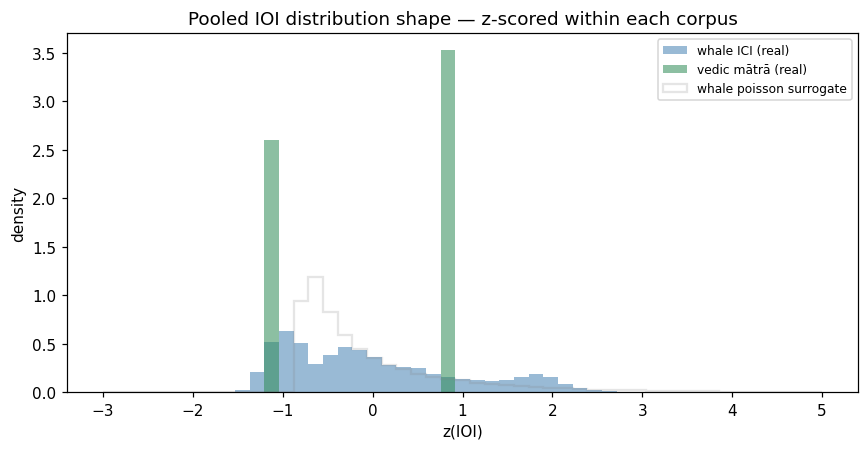

KS distance whale_real ↔ vedic_real (z-scored): D=0.374
Within-corpus real ↔ structure-destroying-null KS: whale=0.225, vedic=0.000
Non-trivial surrogate floor: 0.225


In [3]:
def zscore(a):
    a = np.asarray(a, dtype=float)
    return (a - a.mean()) / a.std(ddof=0)

whale_pool = features.pooled_ioi(whale_ici)
vedic_pool = features.pooled_ioi(vedic_durations)

# Surrogate baselines for the verdict line.
whale_within = swstats.surrogate_shuffle_within(whale_ici, RNG)
whale_poisson = swstats.surrogate_poisson(whale_ici, RNG)
vedic_within = swstats.surrogate_shuffle_within(vedic_weights, RNG)
_p_L = sum(s.count("L") for s in vedic_weights) / sum(len(s) for s in vedic_weights)
vedic_iid = [RNG.choice(["L", "G"], size=len(s), p=[_p_L, 1 - _p_L]).tolist() for s in vedic_weights]
vedic_iid_dur = [features.weights_to_durations(s).tolist() for s in vedic_iid]

zw, zv = zscore(whale_pool), zscore(vedic_pool)
zwi = zscore(features.pooled_ioi(whale_within))
zwp = zscore(features.pooled_ioi(whale_poisson))
zvi = zscore(features.pooled_ioi(vedic_iid_dur))

fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.linspace(-3, 5, 50)
ax.hist(zw, bins=bins, density=True, alpha=0.55, label="whale ICI (real)", color="steelblue")
ax.hist(zv, bins=bins, density=True, alpha=0.55, label="vedic mātrā (real)", color="seagreen")
ax.hist(zwp, bins=bins, density=True, alpha=0.20, label="whale poisson surrogate", color="grey",
        histtype="step", linewidth=1.5)
ax.set_title("Pooled IOI distribution shape — z-scored within each corpus")
ax.set_xlabel("z(IOI)"); ax.set_ylabel("density")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "04_zscored_ioi.png", bbox_inches="tight")
plt.show()

D_cross, p_cross = swstats.ks_test(zw, zv)
# Within-corpus comparisons use raw (not z-scored) pools because the shuffle
# surrogates trivially preserve the multiset; the meaningful surrogates here
# are poisson (whale) and i.i.d. L/G (vedic).
D_w_poisson, _ = swstats.ks_test(whale_pool, features.pooled_ioi(whale_poisson))
D_v_iid, _    = swstats.ks_test(vedic_pool, features.pooled_ioi(vedic_iid_dur))

floor = max(D_w_poisson, D_v_iid)
print(f"KS distance whale_real ↔ vedic_real (z-scored): D={D_cross:.3f}")
print(f"Within-corpus real ↔ structure-destroying-null KS: whale={D_w_poisson:.3f}, vedic={D_v_iid:.3f}")
print(f"Non-trivial surrogate floor: {floor:.3f}")


## Headline 3 — n-gram entropy of real vs surrogate

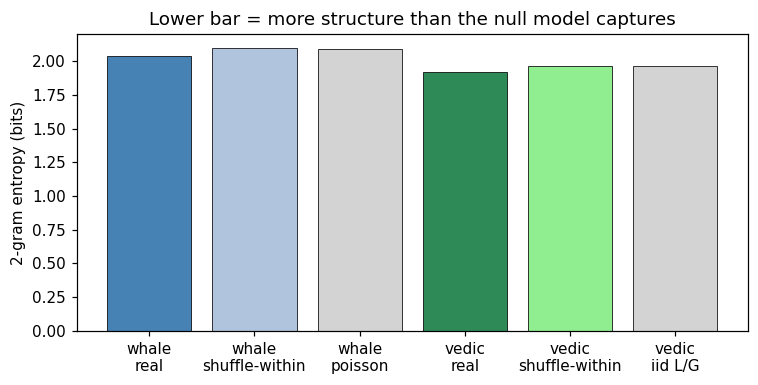

whale: real=2.038, within=2.096, poisson=2.088
vedic: real=1.922, within=1.966, iid=1.967


In [4]:
def _whale_h(seqs):
    return features.whale_ngram_entropy(seqs, n=2, n_bins=5)
def _vedic_h(seqs):
    return features.vedic_ngram_entropy(seqs, n=2)

whale_h_real = _whale_h(whale_ici)
whale_h_within = _whale_h(whale_within)
whale_h_poisson = _whale_h(whale_poisson)
vedic_h_real = _vedic_h(vedic_weights)
vedic_h_within = _vedic_h(vedic_within)
vedic_h_iid = _vedic_h(vedic_iid)

fig, ax = plt.subplots(figsize=(7, 3.6))
labels = ["whale\nreal", "whale\nshuffle-within", "whale\npoisson",
          "vedic\nreal", "vedic\nshuffle-within", "vedic\niid L/G"]
vals = [whale_h_real, whale_h_within, whale_h_poisson,
        vedic_h_real, vedic_h_within, vedic_h_iid]
colors = ["steelblue", "lightsteelblue", "lightgrey",
          "seagreen", "lightgreen", "lightgrey"]
ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("2-gram entropy (bits)")
ax.set_title("Lower bar = more structure than the null model captures")
fig.tight_layout()
fig.savefig(FIGURES / "04_ngram_entropy.png", bbox_inches="tight")
plt.show()

print(f"whale: real={whale_h_real:.3f}, within={whale_h_within:.3f}, poisson={whale_h_poisson:.3f}")
print(f"vedic: real={vedic_h_real:.3f}, within={vedic_h_within:.3f}, iid={vedic_h_iid:.3f}")


## Verdict

Strict reading: a structural-resonance claim requires the cross-corpus distance
to be **smaller** than the worst within-corpus real-vs-surrogate distance. The
cell below prints the verdict; copy the bolded line into the README.


In [5]:
if D_cross < floor:
    verdict = (f"**Weak structural similarity detected** — cross-corpus z-scored IOI distance "
               f"D={D_cross:.3f} is below the worst within-corpus real-vs-surrogate distance "
               f"D={floor:.3f}. See notebook 03 for the full breakdown.")
else:
    verdict = (f"**No structural resonance detected beyond what surrogate sequences produce.** "
               f"The z-scored pooled-IOI distance between real whale codas and real Rigvedic pādas "
               f"(KS D={D_cross:.3f}) exceeds the worst real-vs-surrogate distance within either "
               f"corpus (D={floor:.3f}). The two distributions differ in shape by more than each "
               f"corpus differs from its own structure-destroying nulls.")
print(verdict)


**No structural resonance detected beyond what surrogate sequences produce.** The z-scored pooled-IOI distance between real whale codas and real Rigvedic pādas (KS D=0.374) exceeds the worst real-vs-surrogate distance within either corpus (D=0.225). The two distributions differ in shape by more than each corpus differs from its own structure-destroying nulls.
